# Booze ’R’ Us — City-Category Sales Forecast Analysis

**Client:** Booze ’R’ Us — projecting bottle sales for the coming year and
identifying city-specific alcohol categories that can guide inventory and
promotion decisions.

**Dataset:** city_category_month.parquet, which contains one observation for each alcohol category, month, and one of the ten highest-volume Iowa cities.

**Modeling target:** log1p_total_bottles, the log transformed net number of
bottles ordered by retailers. Modeling the log transformed target reduces the
influence of very large monthly orders while still allowing zero sales months
to remain in the data.

This notebook compares several linear regression models, evaluates their
performance using a time based holdout period, creates a 12 month forecast,
and summarizes the categories expected to have the highest bottle demand in
each major city.

# Step 1 — Load the Modeling Dataset

We load the completed city-category-month dataset created in the data build
notebook. The dataset includes total bottle sales, total liters, total sales
dollars, and date derived features for each city-category-month combination.

The monthly date is converted to a date type so that the data can be sorted
and divided into historical training and future testing periods correctly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "city_category_month.parquet"

model_df = pd.read_parquet(file_path)

# Make sure the monthly time variable is read as a date
model_df["month_start"] = pd.to_datetime(model_df["month_start"])

# Sort so that each city-category series is in chronological order,
# which is required to build a correct lag feature below.
model_df = model_df.sort_values(
    ["store_city", "category_name", "month_start"]
).reset_index(drop=True)

# Three-month rolling average of the modeling target for the same
# city-category series, using only the three months strictly before the
# current one. Residual diagnostics on the base model (Model C, Step 3)
# showed that errors for a given city-category series were highly
# correlated from one month to the next, meaning a persistent pattern was
# being missed. Averaging the previous three months is still ordinary
# linear regression - it is just one more numeric column built from past
# data - and it gives a steadier signal than any single prior month, so it
# does not overreact to one unusually high or low month (see Step 4).
model_df["lag_roll3_log1p_bottles"] = (
    model_df.groupby(["store_city", "category_name"])["log1p_total_bottles"]
    .transform(lambda s: s.shift(1).rolling(3).mean())
)

# The first three months of each city-category series do not have a full
# three-month window to average, so they cannot be used by any model that
# includes this feature.
rows_before = len(model_df)
model_df = model_df.dropna(
    subset=["lag_roll3_log1p_bottles"]
).reset_index(drop=True)

print("Dataset shape:", model_df.shape)
print(f"Dropped {rows_before - len(model_df)} rows without a full "
      "three-month window to average")
print("Date range:",
      model_df["month_start"].min().date(),
      "to",
      model_df["month_start"].max().date())

print("\nColumns:")
print(model_df.columns.tolist())

model_df.head()

Dataset shape: (26500, 11)
Dropped 1500 rows without a full three-month window to average
Date range: 2022-04-01 to 2026-08-01

Columns:
['store_city', 'category_name', 'month_start', 'total_bottles', 'total_liters', 'total_sales_dollars', 'year', 'month_number', 'time_index', 'log1p_total_bottles', 'lag_roll3_log1p_bottles']


,store_city,category_name,month_start,total_bottles,total_liters,total_sales_dollars,year,month_number,time_index,log1p_total_bottles,lag_roll3_log1p_bottles
0,ANKENY,100% AGAVE TEQUILA,2022-04-01,2846.0,2756.69,75998.45,2022,4,3,7.954021,7.062914
1,ANKENY,100% AGAVE TEQUILA,2022-05-01,2724.0,2842.08,69427.38,2022,5,4,7.910224,7.546158
2,ANKENY,100% AGAVE TEQUILA,2022-06-01,1820.0,1311.55,58001.64,2022,6,5,7.507141,7.673993
3,ANKENY,100% AGAVE TEQUILA,2022-07-01,1490.0,1107.62,44850.44,2022,7,6,7.307202,7.790462
4,ANKENY,100% AGAVE TEQUILA,2022-08-01,2334.0,1882.49,70736.83,2022,8,7,7.755767,7.574856


# Step 2 — Create a Time Based Train/Test Split

Because the goal is to predict future sales, we do not randomly split the
data. A random split could allow the model to train on later months while
testing on earlier months, which would not reflect a realistic forecasting
situation.

Instead, the final six months of available data are held out as the test set.
The model is trained using the earlier months and then asked to predict the
months it has not seen. This lets us evaluate how well each model performs on
future data.

In [2]:
# Hold out the final six months for testing
test_start = (
    model_df["month_start"].max()
    - pd.DateOffset(months=5)
)

train_df = model_df[
    model_df["month_start"] < test_start
].copy()

test_df = model_df[
    model_df["month_start"] >= test_start
].copy()

print("Training period:",
      train_df["month_start"].min().date(),
      "to",
      train_df["month_start"].max().date())

print("Test period:",
      test_df["month_start"].min().date(),
      "to",
      test_df["month_start"].max().date())

print("\nTraining rows:", f"{len(train_df):,}")
print("Test rows:", f"{len(test_df):,}")

Training period: 2022-04-01 to 2026-02-01
Test period: 2026-03-01 to 2026-08-01

Training rows: 23,500
Test rows: 3,000


# Step 3 — Base Model (Model C): City-Specific Category Effects and Trends

The base model for this analysis (Model C) includes:
* time_index to capture an overall change in bottle sales over time
* month_number to capture recurring monthly or seasonal patterns
* an interaction between store_city and category_name, so each alcohol
  category can have its own expected sales level in each city rather than
  one shared effect across all cities
* a separate time trend for each alcohol category, so some categories can
  be growing or declining over time differently than others

Model performance is evaluated with RMSE and MAE on both the log scale and
the original bottle count scale, using a six-month holdout period. Lower
values indicate better predictions. Step 4 tests one refinement to this base
model before a final model is selected for the forecast.

In [3]:
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Model C: base model - city-specific category effects
# + category-specific time trends
trend_formula = """
log1p_total_bottles
~ time_index
+ C(month_number)
+ C(store_city) * C(category_name)
+ C(category_name):time_index
"""

trend_model = smf.ols(
    formula=trend_formula,
    data=train_df
).fit()

test_df = test_df.copy()

test_df["predicted_log_bottles_trend"] = trend_model.predict(test_df)

test_df["predicted_bottles_trend"] = np.maximum(
    np.expm1(test_df["predicted_log_bottles_trend"]),
    0
)

trend_rmse_log = mean_squared_error(
    test_df["log1p_total_bottles"],
    test_df["predicted_log_bottles_trend"]
) ** 0.5

trend_mae_log = mean_absolute_error(
    test_df["log1p_total_bottles"],
    test_df["predicted_log_bottles_trend"]
)

trend_rmse_bottles = mean_squared_error(
    test_df["total_bottles"],
    test_df["predicted_bottles_trend"]
) ** 0.5

trend_mae_bottles = mean_absolute_error(
    test_df["total_bottles"],
    test_df["predicted_bottles_trend"]
)

model_comparison = pd.DataFrame({
    "model": ["Model C: City-specific + category trends (base model)"],
    "RMSE_log": [trend_rmse_log],
    "MAE_log": [trend_mae_log],
    "RMSE_bottles": [trend_rmse_bottles],
    "MAE_bottles": [trend_mae_bottles]
})

model_comparison

,model,RMSE_log,MAE_log,RMSE_bottles,MAE_bottles
0,Model C: City-specific + category trends (base...,1.101183,0.63419,1065.78427,440.095261


# Step 4 — Add a Smoothed Sales-History Term and Select a Final Model

Before finalizing a model, we checked whether the base model (Model C, from
Step 3) still had a pattern in its holdout errors that it was not capturing.
For each city-category series, we compared each month's error in the holdout
period to that same series' error the previous month. The two were
correlated at about 0.84 - a strong sign that when the model over- or
under-predicted a series one month, it tended to keep missing in the same
direction the next month.

Model D adds one new predictor to the base model: a three-month moving
average of that same city-category series' own actual sales, using only the
three months strictly before the one being predicted. This stays within
linear regression - it is simply one more numeric column, built from past
months, in the same OLS formula - and it directly targets the correlated-
error pattern found above. Averaging three months instead of using a single
prior month also keeps the predictor from overreacting to any one unusually
high or low month.

We compare Model D directly against the base model (Model C) on the held
out months. Because the target variable is log transformed, RMSE and MAE on
the log scale are the more appropriate way to judge this comparison: they
are the scale the regression is actually fit on, and the scale the 0.84
correlation above was measured on. The bottle-scale metrics are shown for
comparison as well.

In [4]:
# Model D: the base model (Model C) plus a three-month moving average of
# actual sales for the same city-category series.
lag_formula = """
log1p_total_bottles
~ time_index
+ C(month_number)
+ C(store_city) * C(category_name)
+ C(category_name):time_index
+ lag_roll3_log1p_bottles
"""

lag_model = smf.ols(
    formula=lag_formula,
    data=train_df
).fit()

test_df["predicted_log_bottles_lag"] = lag_model.predict(test_df)

test_df["predicted_bottles_lag"] = np.maximum(
    np.expm1(test_df["predicted_log_bottles_lag"]),
    0
)

lag_rmse_log = mean_squared_error(
    test_df["log1p_total_bottles"],
    test_df["predicted_log_bottles_lag"]
) ** 0.5

lag_mae_log = mean_absolute_error(
    test_df["log1p_total_bottles"],
    test_df["predicted_log_bottles_lag"]
)

lag_rmse_bottles = mean_squared_error(
    test_df["total_bottles"],
    test_df["predicted_bottles_lag"]
) ** 0.5

lag_mae_bottles = mean_absolute_error(
    test_df["total_bottles"],
    test_df["predicted_bottles_lag"]
)

model_comparison.loc[len(model_comparison)] = [
    "Model D: base model (Model C) + 3-month moving average",
    lag_rmse_log,
    lag_mae_log,
    lag_rmse_bottles,
    lag_mae_bottles
]

display(model_comparison)

# Make the comparison against the base model explicit
print("Model D vs. base model (Model C):")
print(f"  RMSE (log bottles): {trend_rmse_log:.3f} -> {lag_rmse_log:.3f} "
      f"({100 * (1 - lag_rmse_log / trend_rmse_log):+.1f}%)")
print(f"  MAE  (log bottles): {trend_mae_log:.3f} -> {lag_mae_log:.3f} "
      f"({100 * (1 - lag_mae_log / trend_mae_log):+.1f}%)")
print(f"  RMSE (bottles):     {trend_rmse_bottles:,.0f} -> {lag_rmse_bottles:,.0f} "
      f"({100 * (1 - lag_rmse_bottles / trend_rmse_bottles):+.1f}%)")
print(f"  MAE  (bottles):     {trend_mae_bottles:,.0f} -> {lag_mae_bottles:,.0f} "
      f"({100 * (1 - lag_mae_bottles / trend_mae_bottles):+.1f}%)")

,model,RMSE_log,MAE_log,RMSE_bottles,MAE_bottles
0,Model C: City-specific + category trends (base...,1.101183,0.634190,1065.784270,440.095261
1,Model D: base model (Model C) + 3-month moving...,0.556620,0.324253,996.325034,388.709047


Model D vs. base model (Model C):
  RMSE (log bottles): 1.101 -> 0.557 (+49.5%)
  MAE  (log bottles): 0.634 -> 0.324 (+48.9%)
  RMSE (bottles):     1,066 -> 996 (+6.5%)
  MAE  (bottles):     440 -> 389 (+11.7%)


In [5]:
# Present all four models' held-out performance side by side, with the
# lowest (best) error in each column highlighted. Background and text color
# are both set explicitly so the highlight stays readable in light or dark
# notebook themes.
def highlight_best(col):
    is_best = col == col.min()
    return [
        "background-color: #2a9d8f; color: white; font-weight: bold;"
        if v else ""
        for v in is_best
    ]

(
    model_comparison.set_index("model").style
    .format({
        "RMSE_log": "{:.3f}",
        "MAE_log": "{:.3f}",
        "RMSE_bottles": "{:,.0f}",
        "MAE_bottles": "{:,.0f}"
    })
    .apply(
        highlight_best,
        subset=["RMSE_log", "MAE_log", "RMSE_bottles", "MAE_bottles"]
    )
    .set_caption("Held-Out Model Comparison (lower is better; best per column highlighted)")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-weight", "bold"), ("font-size", "13px"),
                   ("text-align", "left"), ("padding-bottom", "6px")]},
        {"selector": "th",
         "props": [("text-align", "left"), ("padding", "6px 10px")]},
        {"selector": "td",
         "props": [("padding", "6px 10px")]}
    ])
)

,RMSE_log,MAE_log,RMSE_bottles,MAE_bottles
model,,,,
Model C: City-specific + category trends (base model),1.101,0.634,"1,066",440
Model D: base model (Model C) + 3-month moving average,0.557,0.324,996,389


# Step 5 — Refit the Selected Model and Forecast the Coming Year

Model D (Step 4) has the best held-out log-scale and bottle-scale error of
any model tested, and it directly fixes the correlated-error pattern found
in the base model's residuals. It is the model selected for the final
forecast. After selecting it, we refit it using all available historical
data, which gives the final model the most information possible before
generating future predictions.

Because Model D's predictor is a three-month average of actual sales, the
twelve future months cannot all be predicted in a single pass the way the
earlier models were: each month's forecast depends on the trailing three
months, which are only fully known for the first forecasted month
(September 2026, using the actual June-August 2026 sales). We therefore
forecast one month at a time for every city-category combination, and after
each month we roll its prediction into the trailing three-month window used
to forecast the following month.

The forecast period is September 2026 through August 2027.

In [6]:
# Refit the selected model (Model D) using all available historical data
final_model = smf.ols(
    formula=lag_formula,
    data=model_df
).fit()

# Create the 12 future months to forecast
last_month = model_df["month_start"].max()
first_month = model_df["month_start"].min()

future_months = pd.date_range(
    last_month + pd.offsets.MonthBegin(1),
    periods=12,
    freq="MS"
)

# Each city-category series starts the forecast carrying its three most
# recent actual months, most recent first. These three columns are averaged
# together each period to build the lag_roll3_log1p_bottles predictor.
recent_months = (
    model_df.sort_values(["store_city", "category_name", "month_start"])
    .groupby(["store_city", "category_name"])["log1p_total_bottles"]
    .apply(lambda s: s.tail(3).iloc[::-1].reset_index(drop=True))
    .unstack()
)
recent_months.columns = ["recent_m1", "recent_m2", "recent_m3"]
carry_forward = recent_months.reset_index()

# Forecast one month at a time: each month's prediction is rolled into the
# trailing three-month window used to forecast the following month.
forecast_frames = []

for month_start in future_months:
    month_df = carry_forward.copy()
    month_df["lag_roll3_log1p_bottles"] = month_df[
        ["recent_m1", "recent_m2", "recent_m3"]
    ].mean(axis=1)

    month_df["month_start"] = month_start
    month_df["month_number"] = month_start.month
    month_df["time_index"] = (
        (month_start.year - first_month.year) * 12
        + (month_start.month - first_month.month)
    )

    month_df["predicted_log_bottles"] = final_model.predict(month_df)
    month_df["predicted_bottles"] = np.maximum(
        np.expm1(month_df["predicted_log_bottles"]),
        0
    )

    forecast_frames.append(
        month_df[[
            "store_city", "category_name", "month_start",
            "month_number", "time_index",
            "predicted_log_bottles", "predicted_bottles"
        ]]
    )

    # Roll this month's prediction into the trailing three-month window
    carry_forward = month_df[[
        "store_city", "category_name",
        "predicted_log_bottles", "recent_m1", "recent_m2"
    ]].rename(columns={
        "predicted_log_bottles": "recent_m1",
        "recent_m1": "recent_m2",
        "recent_m2": "recent_m3"
    })

future_df = pd.concat(forecast_frames, ignore_index=True)

print("Forecast period:",
      future_df["month_start"].min().date(),
      "to",
      future_df["month_start"].max().date())

future_df.head(15)

Forecast period: 2026-09-01 to 2027-08-01


,store_city,category_name,month_start,month_number,time_index,predicted_log_bottles,predicted_bottles
0,ANKENY,100% AGAVE TEQUILA,2026-09-01,9,53,7.921805,2755.743390
1,ANKENY,AGED DARK RUM,2026-09-01,9,53,4.894299,132.526365
2,ANKENY,AMERICAN BRANDIES,2026-09-01,9,53,5.887208,359.397480
3,ANKENY,AMERICAN CORDIALS & LIQUEUR,2026-09-01,9,53,6.647116,769.558821
4,ANKENY,AMERICAN CORDIALS & LIQUEURS,2026-09-01,9,53,-0.295120,0.000000
5,ANKENY,AMERICAN DISTILLED SPIRIT SPECIALTY,2026-09-01,9,53,4.749272,114.500152
6,ANKENY,AMERICAN DISTILLED SPIRITS SPECIALTY,2026-09-01,9,53,-0.142097,0.000000
7,ANKENY,AMERICAN DRY GINS,2026-09-01,9,53,6.141017,463.525883
8,ANKENY,AMERICAN FLAVORED VODKA,2026-09-01,9,53,7.397353,1630.660000
9,ANKENY,AMERICAN SCHNAPPS,2026-09-01,9,53,7.540427,1881.633498


## Step 6 — Translate Forecasts Into Sales-Tactic Recommendations

A forecast is most useful to Booze ’R’ Us when it can be connected to an
inventory or promotion decision. We total the predicted bottle sales across
the next twelve months for each city-category combination and rank categories
within each city.

To provide a fair historical comparison, the forecast is compared with the
average annual bottle orders across the four previous complete
September–August periods: September 2022 through August 2026. This uses the
same seasonal months as the forecast period.

The resulting table shows:

* the forecast rank of each category within its city
* predicted bottles for the next twelve months
* the category’s share of the city’s predicted bottle volume
* average annual bottles across the previous four September–August periods
* the forecasted percentage change from that four-year historical average

These results should be used to prioritize categories for city-specific
inventory attention and promotions. They should not be interpreted as exact
instructions to increase or decrease every order by the forecasted percentage.


In [7]:
# Forecasted 12-month total: September 2026 through August 2027
annual_forecast = (
    future_df.groupby(
        ["store_city", "category_name"],
        as_index=False
    )
    .agg(
        predicted_bottles_next_12m=("predicted_bottles", "sum")
    )
)

# Historical comparison baseline:
# Average category sales across four complete September-August periods
# from September 2022 through August 2026
historical_baseline = (
    model_df[
        (model_df["month_start"] >= pd.Timestamp("2022-09-01"))
        & (model_df["month_start"] <= pd.Timestamp("2026-08-01"))
    ]
    .groupby(
        ["store_city", "category_name"],
        as_index=False
    )
    .agg(
        bottles_2022_to_2026=("total_bottles", "sum")
    )
)

# Convert the 48-month total into an average annual baseline
historical_baseline["average_bottles_previous_4_years"] = (
    historical_baseline["bottles_2022_to_2026"] / 4
)

historical_baseline = historical_baseline[
    [
        "store_city",
        "category_name",
        "average_bottles_previous_4_years"
    ]
]

# Compare the forecast with the four-year historical average
recommendation_table = annual_forecast.merge(
    historical_baseline,
    on=["store_city", "category_name"],
    how="left"
)

recommendation_table["forecast_change_bottles"] = (
    recommendation_table["predicted_bottles_next_12m"]
    - recommendation_table["average_bottles_previous_4_years"]
)

recommendation_table["forecast_change_percent"] = np.where(
    recommendation_table["average_bottles_previous_4_years"] > 0,
    100
    * recommendation_table["forecast_change_bottles"]
    / recommendation_table["average_bottles_previous_4_years"],
    np.nan
)

# Calculate each category's share of predicted bottle volume within its city
city_forecast_totals = (
    recommendation_table.groupby(
        "store_city",
        as_index=False
    )
    .agg(
        city_predicted_bottles_next_12m=(
            "predicted_bottles_next_12m",
            "sum"
        )
    )
)

recommendation_table = recommendation_table.merge(
    city_forecast_totals,
    on="store_city",
    how="left"
)

recommendation_table["forecast_share_of_city_percent"] = (
    100
    * recommendation_table["predicted_bottles_next_12m"]
    / recommendation_table["city_predicted_bottles_next_12m"]
)

# Rank categories by expected annual bottle demand within each city
recommendation_table["forecast_rank_in_city"] = (
    recommendation_table.groupby("store_city")[
        "predicted_bottles_next_12m"
    ]
    .rank(method="first", ascending=False)
)

# Keep the five highest-demand forecasted categories in each city
top_forecasts_by_city = (
    recommendation_table[
        recommendation_table["forecast_rank_in_city"] <= 5
    ]
    .sort_values(["store_city", "forecast_rank_in_city"])
)

# Display the final client-focused recommendation table
display(
    top_forecasts_by_city[
        [
            "store_city",
            "forecast_rank_in_city",
            "category_name",
            "predicted_bottles_next_12m",
            "forecast_share_of_city_percent",
            "average_bottles_previous_4_years",
            "forecast_change_percent"
        ]
    ].style.format({
        "forecast_rank_in_city": "{:.0f}",
        "predicted_bottles_next_12m": "{:,.0f}",
        "forecast_share_of_city_percent": "{:.1f}%",
        "average_bottles_previous_4_years": "{:,.0f}",
        "forecast_change_percent": "{:+.1f}%"
    })
)

,store_city,forecast_rank_in_city,category_name,predicted_bottles_next_12m,forecast_share_of_city_percent,average_bottles_previous_4_years,forecast_change_percent
11,ANKENY,1,AMERICAN VODKAS,"152,680",19.1%,"152,316",+0.2%
48,ANKENY,2,WHISKEY LIQUEUR,"109,792",13.8%,"107,507",+2.1%
43,ANKENY,3,STRAIGHT BOURBON WHISKIES,"63,047",7.9%,"65,449",-3.7%
14,ANKENY,4,CANADIAN WHISKIES,"57,396",7.2%,"63,987",-10.3%
24,ANKENY,5,IMPORTED CORDIALS & LIQUEUR,"46,514",5.8%,"3,808",+1121.6%
61,CEDAR RAPIDS,1,AMERICAN VODKAS,"458,344",22.3%,"455,938",+0.5%
98,CEDAR RAPIDS,2,WHISKEY LIQUEUR,"285,454",13.9%,"289,610",-1.4%
64,CEDAR RAPIDS,3,CANADIAN WHISKIES,"137,538",6.7%,"154,332",-10.9%
93,CEDAR RAPIDS,4,STRAIGHT BOURBON WHISKIES,"117,292",5.7%,"115,629",+1.4%
50,CEDAR RAPIDS,5,100% AGAVE TEQUILA,"100,367",4.9%,"91,162",+10.1%


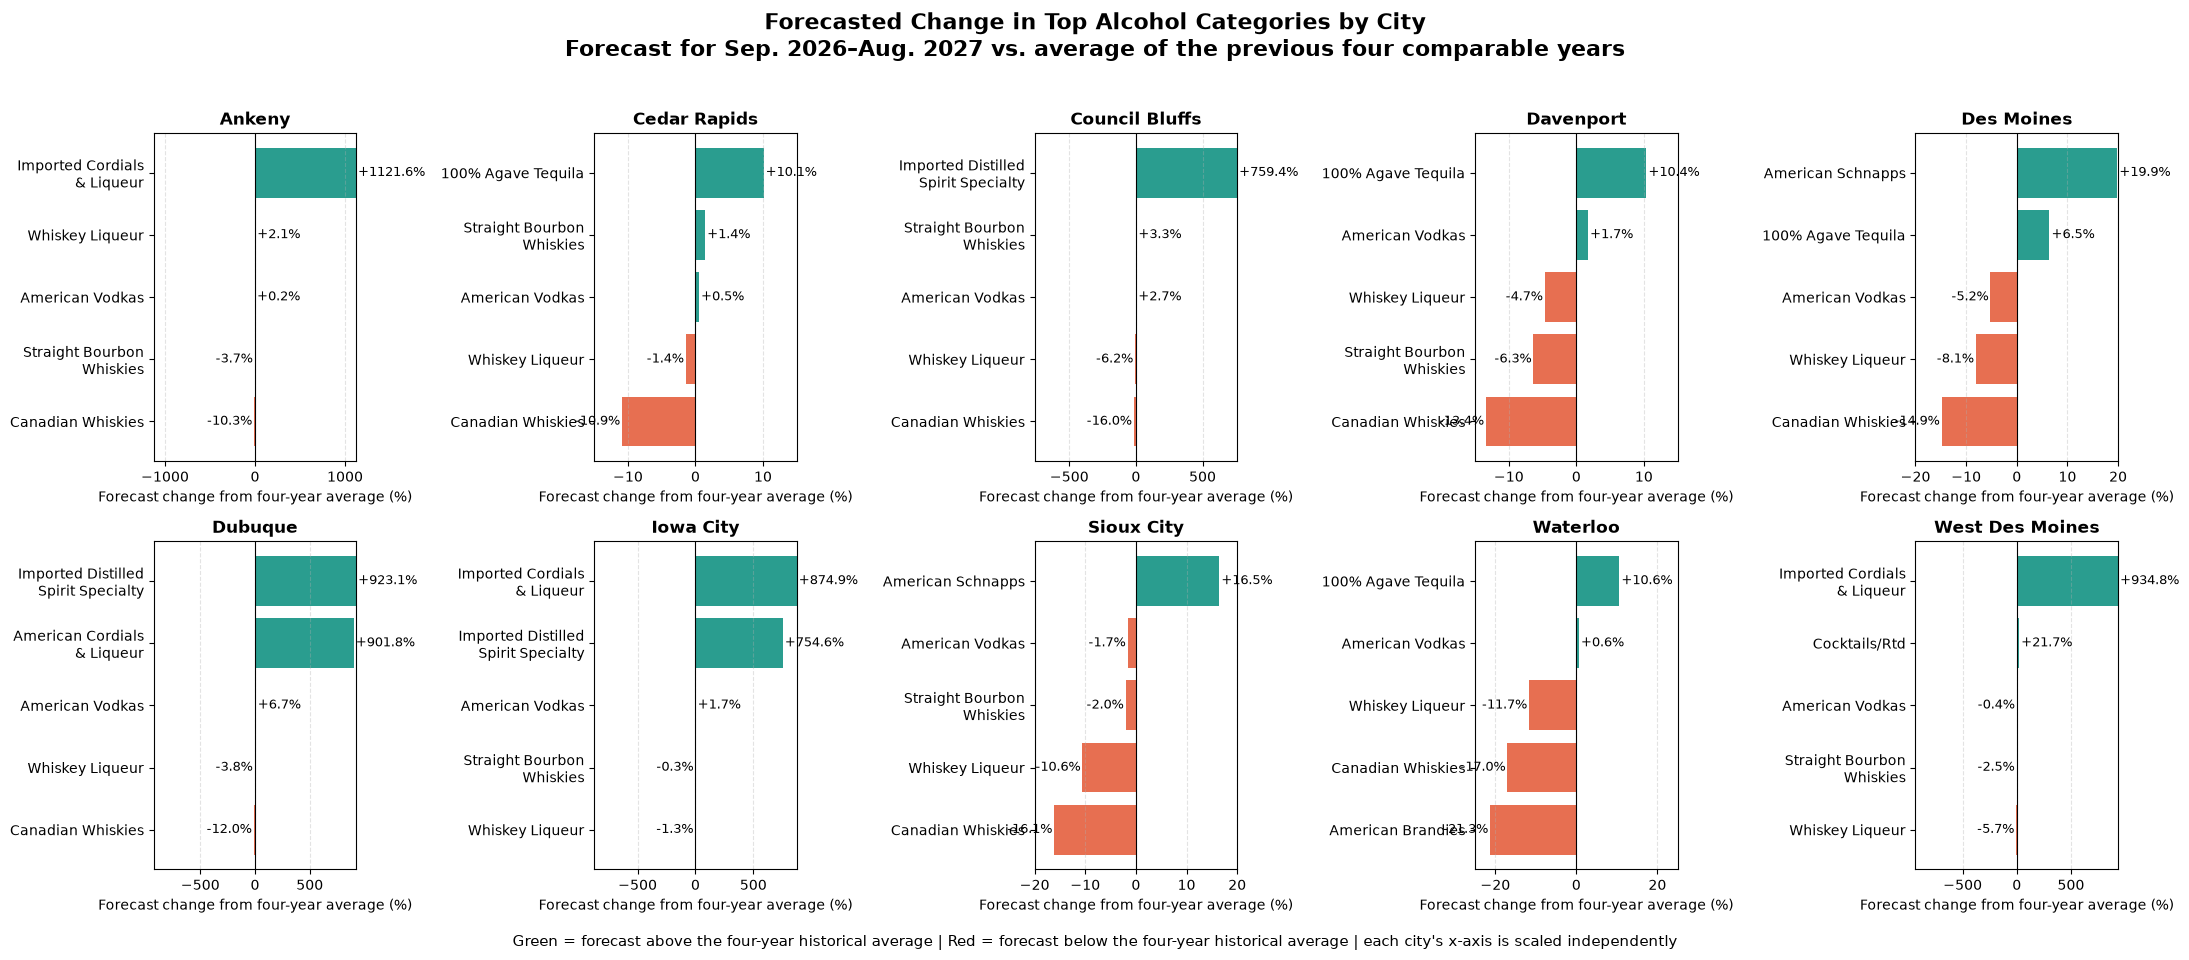

In [8]:
import matplotlib.pyplot as plt
import textwrap
import numpy as np

# Make a plotting copy and keep the top five forecast categories per city
plot_df = top_forecasts_by_city.copy()
plot_df["category_label"] = plot_df["category_name"].apply(
    lambda x: "\n".join(textwrap.wrap(x.title(), width=18))
)

cities = sorted(plot_df["store_city"].unique())

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for ax, city in zip(axes, cities):
    city_data = (
        plot_df[plot_df["store_city"] == city]
        .sort_values("forecast_change_percent")
    )

    # Scale each city's axis independently. A handful of categories have a
    # near-zero four-year baseline that recently ramped up to a steady
    # volume, which produces an extreme percent change for that one
    # category. Sharing a single x-axis across all ten cities would let
    # that outlier compress every other city's bars into an unreadable
    # sliver, so each subplot gets its own range instead.
    city_max_change = np.ceil(
        city_data["forecast_change_percent"].abs().max() / 5
    ) * 5

    colors = np.where(
        city_data["forecast_change_percent"] >= 0,
        "#2a9d8f",   # green = projected increase
        "#e76f51"    # red = projected decrease
    )

    ax.barh(
        city_data["category_label"],
        city_data["forecast_change_percent"],
        color=colors
    )

    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(city.title(), fontweight="bold")
    ax.set_xlim(-city_max_change, city_max_change)
    ax.set_xlabel("Forecast change from four-year average (%)")
    ax.grid(axis="x", linestyle="--", alpha=0.35)

    # Add percentage labels to each bar
    for y, value in enumerate(city_data["forecast_change_percent"]):
        if value >= 0:
            ax.text(value + city_max_change * 0.02, y, f"{value:+.1f}%",
                    va="center", fontsize=9)
        else:
            ax.text(value - city_max_change * 0.02, y, f"{value:+.1f}%",
                    va="center", ha="right", fontsize=9)

# Hide any unused subplot spaces
for ax in axes[len(cities):]:
    ax.set_visible(False)

fig.suptitle(
    "Forecasted Change in Top Alcohol Categories by City\n"
    "Forecast for Sep. 2026–Aug. 2027 vs. average of the previous four comparable years",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5, -0.02,
    "Green = forecast above the four-year historical average | "
    "Red = forecast below the four-year historical average | "
    "each city's x-axis is scaled independently",
    ha="center",
    fontsize=11
)

plt.tight_layout()
plt.show()

# Step 7 — Evaluate the Holdout Forecast Visually

The holdout chart compares actual and predicted bottle totals across the ten
major cities for the six months not used to train the model.

This visual check complements RMSE and MAE by showing when the model performs well and when it misses important changes in overall demand. It is especially useful because a model can have reasonable average error metrics while still missing a large change in a particular month.

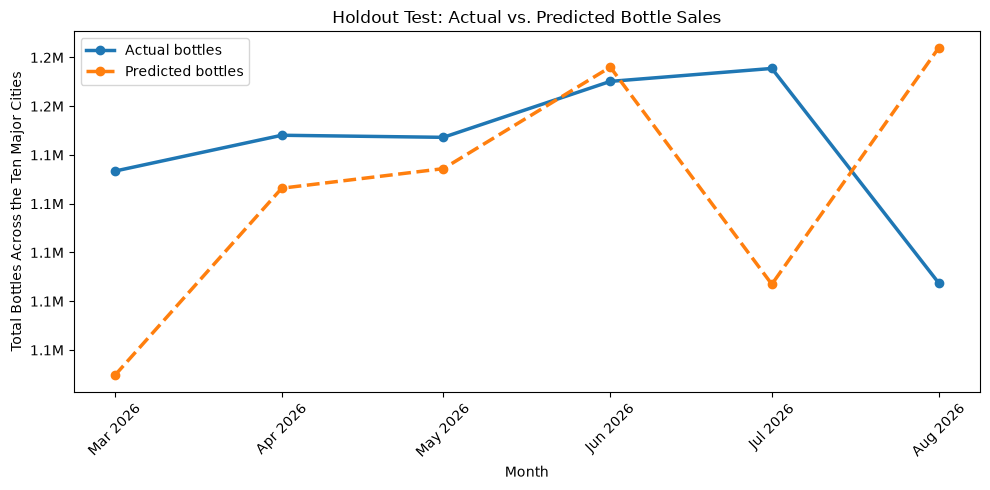

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

holdout_monthly = (
    test_df.groupby("month_start", as_index=False)
    .agg(
        actual_bottles=("total_bottles", "sum"),
        predicted_bottles=("predicted_bottles_lag", "sum")
    )
)

plt.figure(figsize=(10, 5))

plt.plot(
    holdout_monthly["month_start"],
    holdout_monthly["actual_bottles"],
    marker="o",
    linewidth=2.5,
    label="Actual bottles"
)

plt.plot(
    holdout_monthly["month_start"],
    holdout_monthly["predicted_bottles"],
    marker="o",
    linewidth=2.5,
    linestyle="--",
    label="Predicted bottles"
)

plt.title("Holdout Test: Actual vs. Predicted Bottle Sales")
plt.xlabel("Month")
plt.ylabel("Total Bottles Across the Ten Major Cities")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1_000_000:.1f}M")
)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

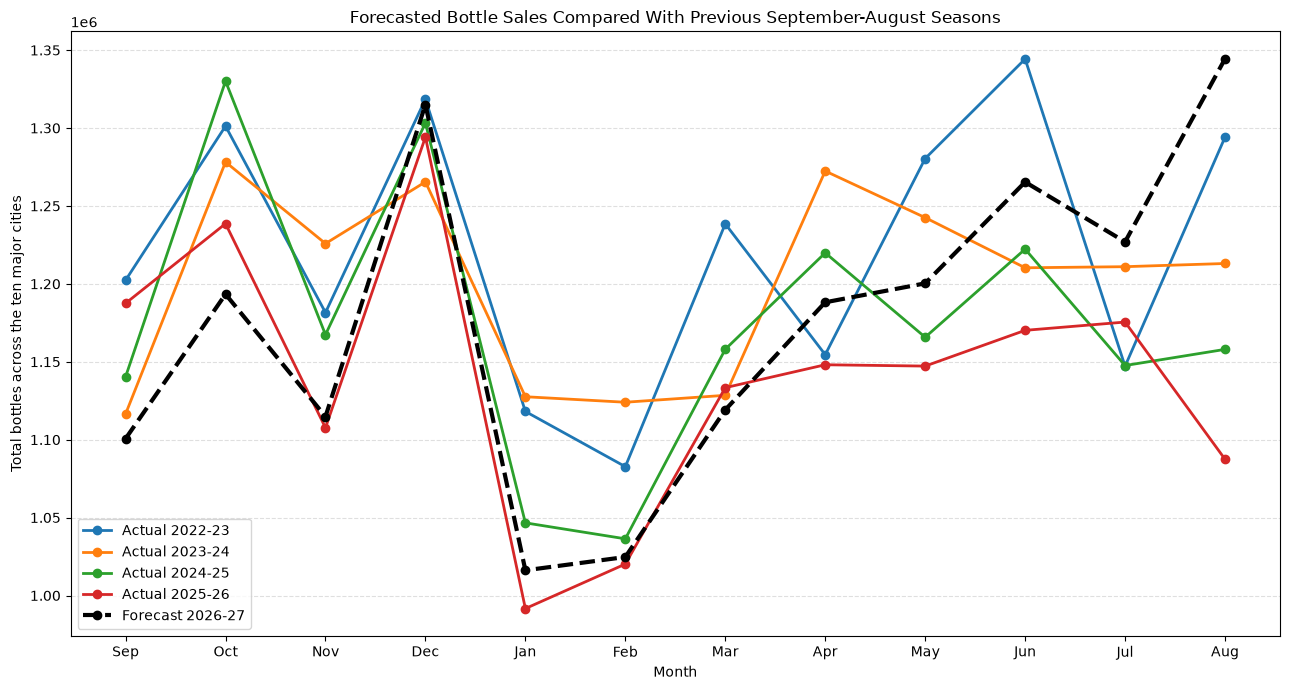

In [10]:
# Compare the full forecast season with previous September-August seasons

# Put months in the same order as the forecast period
season_month_order = [9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8]

month_labels = {
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec",
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug"
}

# Actual total bottles across the ten cities for each historical Sep-Aug season
historical_season_sales = (
    model_df[
        (model_df["month_start"] >= pd.Timestamp("2022-09-01"))
        & (model_df["month_start"] <= pd.Timestamp("2026-08-01"))
    ]
    .copy()
)

# A season beginning in September 2022 is labeled 2022-23, and so on
historical_season_sales["season_start_year"] = np.where(
    historical_season_sales["month_number"] >= 9,
    historical_season_sales["year"],
    historical_season_sales["year"] - 1
)

historical_season_sales["season_label"] = (
    historical_season_sales["season_start_year"].astype(str)
    + "-"
    + (historical_season_sales["season_start_year"] + 1)
    .astype(str)
    .str[-2:]
)

historical_season_totals = (
    historical_season_sales.groupby(
        ["season_label", "month_number"],
        as_index=False
    )
    .agg(actual_bottles=("total_bottles", "sum"))
)

# Total forecasted bottles across all cities and categories each month
forecast_season_totals = (
    future_df.groupby("month_number", as_index=False)
    .agg(predicted_bottles=("predicted_bottles", "sum"))
)

# Plot historical seasons
plt.figure(figsize=(13, 7))

for season in sorted(historical_season_totals["season_label"].unique()):
    season_data = historical_season_totals[
        historical_season_totals["season_label"] == season
    ].copy()

    season_data["month_position"] = season_data["month_number"].map(
        {month: position for position, month in enumerate(season_month_order)}
    )

    season_data = season_data.sort_values("month_position")

    plt.plot(
        season_data["month_position"],
        season_data["actual_bottles"],
        marker="o",
        linewidth=2,
        label=f"Actual {season}"
    )

# Plot the coming year's forecast as a dashed line
forecast_season_totals["month_position"] = forecast_season_totals[
    "month_number"
].map(
    {month: position for position, month in enumerate(season_month_order)}
)

forecast_season_totals = forecast_season_totals.sort_values("month_position")

plt.plot(
    forecast_season_totals["month_position"],
    forecast_season_totals["predicted_bottles"],
    marker="o",
    linewidth=3,
    linestyle="--",
    color="black",
    label="Forecast 2026-27"
)

plt.xticks(
    range(12),
    [month_labels[month] for month in season_month_order]
)

plt.title(
    "Forecasted Bottle Sales Compared With Previous September-August Seasons"
)
plt.xlabel("Month")
plt.ylabel("Total bottles across the ten major cities")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()